# Oracle Evaluation — All Checkpoints

**Date:** 2026-03-12

Evaluate epochs 10, 20, 30, 40 across 4 policies (10/50/100/200 demos).
50 rollouts each. 16 checkpoints total.

In [1]:
import sys, os, time
import numpy as np
import json
from pathlib import Path

PROJECT_ROOT = Path("/home1/reishuen/latent_sope")
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(PROJECT_ROOT / "third_party" / "robomimic"))

from latent_sope.robomimic_interface.checkpoints import load_checkpoint
from latent_sope.eval.oracle import oracle_value, save_oracle_result

import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...23}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.embeddings.position_ids                           | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm1.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.l

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Device: cuda


In [2]:
NUM_ROLLOUTS = 50
HORIZON = 60
GAMMA = 1.0

CKPT_BASE = PROJECT_ROOT / "third_party/robomimic/diffusion_policy_trained_models"

POLICIES = {
    "10demos": CKPT_BASE / "lift_diffusion_10demos" / "20260311115828",
    "50demos": CKPT_BASE / "lift_diffusion_50demos" / "20260311134204",
    "100demos": CKPT_BASE / "lift_diffusion_100demos" / "20260311135551",
    "200demos": CKPT_BASE / "lift_diffusion_200demos" / "20260311141036",
}

EPOCHS = [10, 20, 30, 40]

RESULTS_DIR = PROJECT_ROOT / "results" / "2026-03-12"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Verify all checkpoints exist
for name, run_dir in POLICIES.items():
    for epoch in EPOCHS:
        ckpt_file = run_dir / "models" / f"model_epoch_{epoch}.pth"
        status = "OK" if ckpt_file.exists() else "MISSING"
        print(f"{name:>10s} epoch {epoch:>2d}: {status}")

   10demos epoch 10: OK
   10demos epoch 20: OK
   10demos epoch 30: OK
   10demos epoch 40: OK
   50demos epoch 10: OK
   50demos epoch 20: OK
   50demos epoch 30: OK
   50demos epoch 40: OK
  100demos epoch 10: OK
  100demos epoch 20: OK
  100demos epoch 30: OK
  100demos epoch 40: OK
  200demos epoch 10: OK
  200demos epoch 20: OK
  200demos epoch 30: OK
  200demos epoch 40: OK


In [ ]:
results = {}

for name, run_dir in POLICIES.items():
    for epoch in EPOCHS:
        key = f"{name}_epoch{epoch}"
        ckpt_path = f"models/model_epoch_{epoch}.pth"
        
        print(f"\n{'='*60}")
        print(f"Evaluating: {key}")
        print(f"{'='*60}")
        
        t0 = time.time()
        try:
            ckpt = load_checkpoint(str(run_dir), ckpt_path=ckpt_path)
            result = oracle_value(
                ckpt,
                num_rollouts=NUM_ROLLOUTS,
                horizon=HORIZON,
                gamma=GAMMA,
                device=device,
                verbose=True,
                num_workers=0,
            )
            elapsed = time.time() - t0
            
            success_rate = float(np.mean(result.returns > 0))
            results[key] = {
                "policy": name,
                "epoch": epoch,
                "mean_return": result.mean_return,
                "std_return": result.std_return,
                "success_rate": success_rate,
                "returns": result.returns.tolist(),
                "elapsed_sec": elapsed,
            }
            
            print(f"  V^pi = {result.mean_return:.4f} +/- {result.std_return:.4f}")
            print(f"  Success rate = {success_rate*100:.1f}%")
            print(f"  Time: {elapsed:.0f}s")
        except Exception as e:
            elapsed = time.time() - t0
            print(f"  FAILED: {e}")
            results[key] = {"policy": name, "epoch": epoch, "error": str(e)}

In [4]:
print(f"\n{'='*70}")
print(f"ORACLE EVALUATION SUMMARY ({NUM_ROLLOUTS} rollouts each, horizon={HORIZON})")
print(f"{'='*70}")
print(f"{'Checkpoint':>25s} | {'V^pi':>10s} | {'± std':>10s} | {'Success%':>10s} | {'Time(s)':>8s}")
print(f"{'-'*25}-+-{'-'*10}-+-{'-'*10}-+-{'-'*10}-+-{'-'*8}")

for name in ["10demos", "50demos", "100demos", "200demos"]:
    for epoch in EPOCHS:
        key = f"{name}_epoch{epoch}"
        r = results.get(key, {})
        if "error" in r:
            print(f"{key:>25s} | {'FAILED':>10s} |{'':>11s} |{'':>11s} |{'':>9s}")
        elif r:
            print(f"{key:>25s} | {r['mean_return']:>10.4f} | {r['std_return']:>10.4f} | {r['success_rate']*100:>9.1f}% | {r['elapsed_sec']:>8.0f}")

# Save combined results
combined_path = RESULTS_DIR / "oracle_eval_all_checkpoints.json"
with open(combined_path, "w") as f:
    json.dump(results, f, indent=2)
print(f"\nSaved to {combined_path}")


ORACLE EVALUATION SUMMARY (50 rollouts each, horizon=60)
               Checkpoint |       V^pi |      ± std |   Success% |  Time(s)
--------------------------+------------+------------+------------+---------
          10demos_epoch10 |     FAILED |            |            |         
          10demos_epoch20 |     FAILED |            |            |         
          10demos_epoch30 |     FAILED |            |            |         
          10demos_epoch40 |     FAILED |            |            |         
          50demos_epoch10 |     FAILED |            |            |         
          50demos_epoch20 |     FAILED |            |            |         
          50demos_epoch30 |     FAILED |            |            |         
          50demos_epoch40 |     FAILED |            |            |         
         100demos_epoch10 |     FAILED |            |            |         
         100demos_epoch20 |     FAILED |            |            |         
         100demos_epoch30 |   

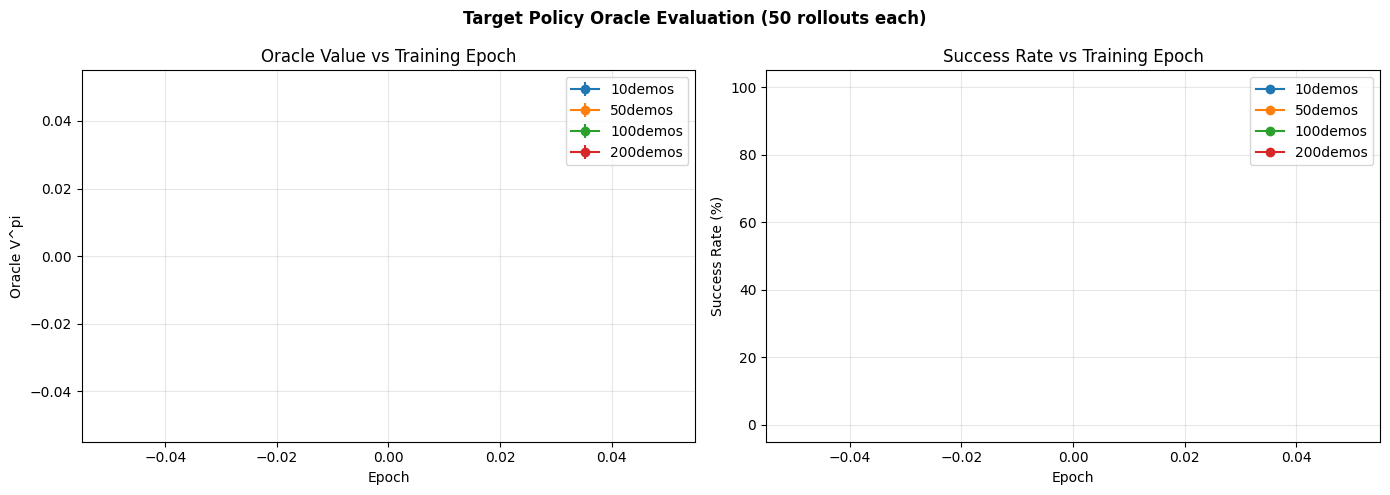

Done!


In [5]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = {"10demos": "C0", "50demos": "C1", "100demos": "C2", "200demos": "C3"}

for name in ["10demos", "50demos", "100demos", "200demos"]:
    epochs_ok = []
    means = []
    stds = []
    sr = []
    for epoch in EPOCHS:
        key = f"{name}_epoch{epoch}"
        r = results.get(key, {})
        if r and "error" not in r:
            epochs_ok.append(epoch)
            means.append(r["mean_return"])
            stds.append(r["std_return"])
            sr.append(r["success_rate"] * 100)
    
    ax1.errorbar(epochs_ok, means, yerr=stds, marker="o", label=name, color=colors[name], capsize=3)
    ax2.plot(epochs_ok, sr, marker="o", label=name, color=colors[name])

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Oracle V^pi")
ax1.set_title("Oracle Value vs Training Epoch")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel("Epoch")
ax2.set_ylabel("Success Rate (%)")
ax2.set_title("Success Rate vs Training Epoch")
ax2.set_ylim(-5, 105)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle(f"Target Policy Oracle Evaluation ({NUM_ROLLOUTS} rollouts each)", fontweight="bold")
plt.tight_layout()
plt.show()

print("Done!")